In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [22]:
df = pd.read_csv(r"diabetes.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [25]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


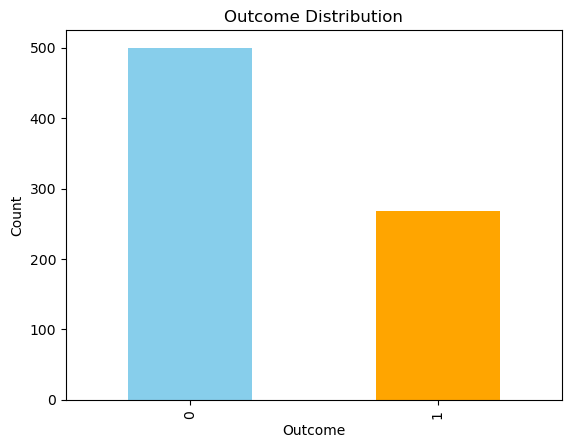

Outcome
0    500
1    268
Name: count, dtype: int64


In [26]:


df["Outcome"].value_counts().plot(
    kind="bar",
    color=["skyblue", "orange"]
)

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

print(df["Outcome"].value_counts())

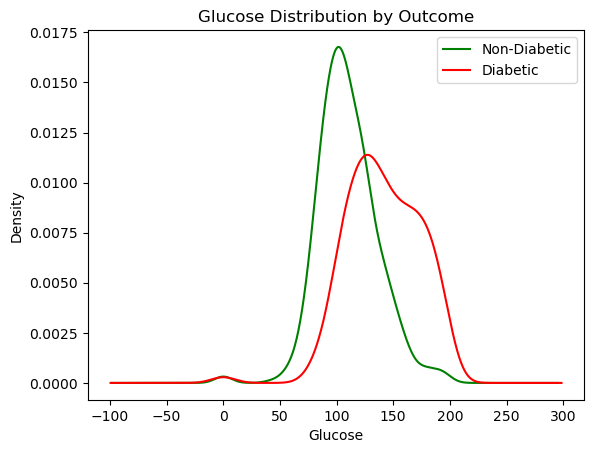

In [27]:


df[df["Outcome"] == 0]["Glucose"].plot(
    kind="kde", color="green", label="Non-Diabetic"
)

df[df["Outcome"] == 1]["Glucose"].plot(
    kind="kde", color="red", label="Diabetic"
)

plt.title("Glucose Distribution by Outcome")
plt.xlabel("Glucose")
plt.legend()
plt.show()

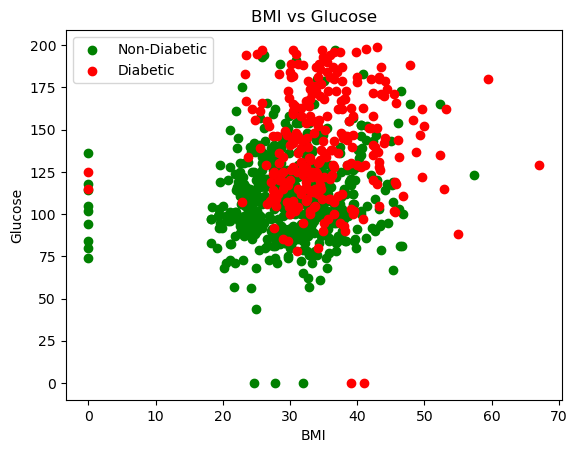

In [28]:
plt.scatter(
    df[df["Outcome"] == 0]["BMI"],
    df[df["Outcome"] == 0]["Glucose"],
    color="green",
    label="Non-Diabetic"
)

plt.scatter(
    df[df["Outcome"] == 1]["BMI"],
    df[df["Outcome"] == 1]["Glucose"],
    color="red",
    label="Diabetic"
)

plt.title("BMI vs Glucose")
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.legend()
plt.show()

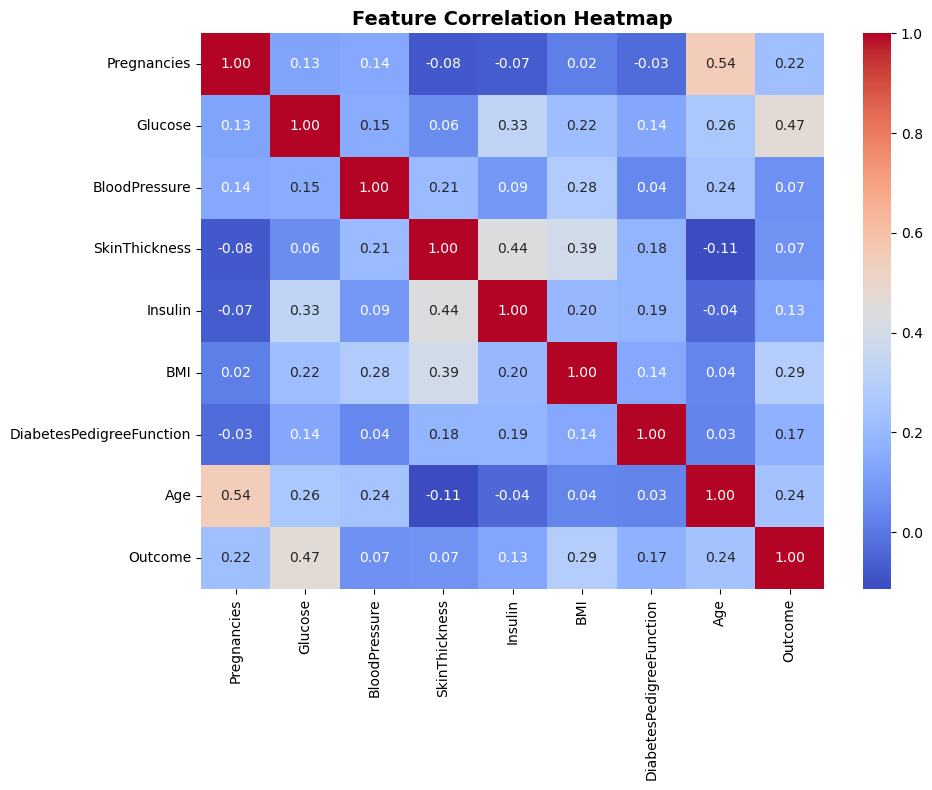

In [29]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# Replace 0 with NaN for biologically impossible values
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("Zero/NaN values after replacement:")
print(df.isnull().sum())

Zero/NaN values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [31]:
# Fill NaN with median
for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after filling with median:")
print(df.isnull().sum())

Missing values after filling with median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [32]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("Class distribution in train:", y_train.value_counts().to_dict())

Train size: (614, 8)
Test size:  (154, 8)
Class distribution in train: {0: 400, 1: 214}


In [33]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight="balanced", n_estimators=300, max_depth=10, random_state=42),
    "SVM":                 SVC(class_weight="balanced", probability=True, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=6, random_state=42, eval_metric="logloss")
}

results = {}

for name, m in models.items():
    m.fit(X_train_sc, y_train)
    y_pred = m.predict(X_test_sc)
    y_prob = m.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(m, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

    results[name] = {"Accuracy": round(acc, 4), "ROC-AUC": round(roc, 4), "CV Accuracy": round(cv, 4)}
    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"5-Fold CV: {cv:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

Model: Logistic Regression
Accuracy : 0.7338
ROC-AUC  : 0.8126
5-Fold CV: 0.7525
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.75      0.79       100
    Diabetic       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

Model: Random Forest
Accuracy : 0.7597
ROC-AUC  : 0.8256
5-Fold CV: 0.7703
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.80      0.81       100
    Diabetic       0.65      0.69      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

Model: SVM
Accuracy : 0.7273
ROC-AUC  : 0.8139
5-Fold CV: 0.7346
              precision    recall  f1-score   support

Non-Diabetic       0.83      0.73      0.78       100
    Diabetic    

                     Accuracy  ROC-AUC  CV Accuracy
Logistic Regression    0.7338   0.8126       0.7525
Random Forest          0.7597   0.8256       0.7703
SVM                    0.7273   0.8139       0.7346
XGBoost                0.7532   0.8044       0.7232


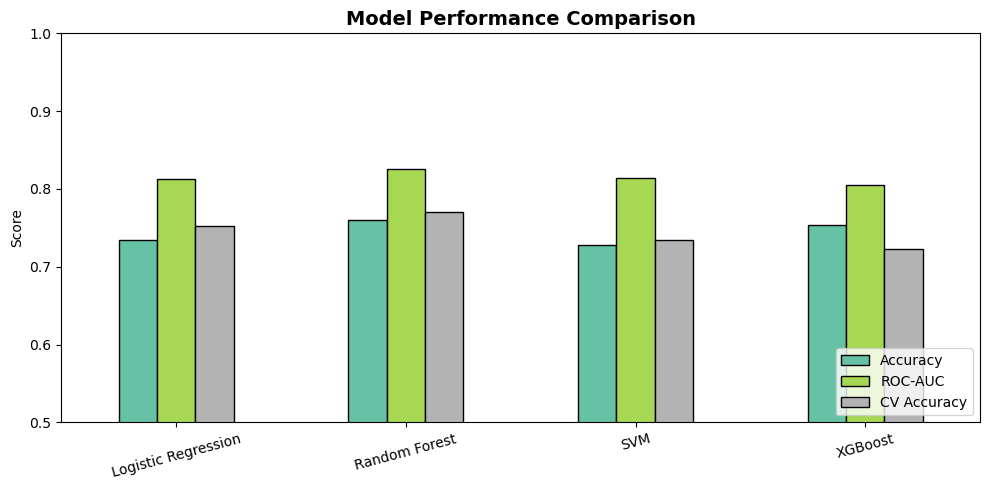

In [34]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="black")
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

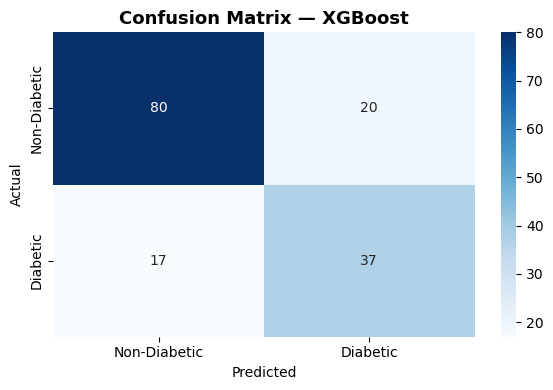

In [35]:
# XGBoost as best model
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"])
plt.title("Confusion Matrix — XGBoost", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

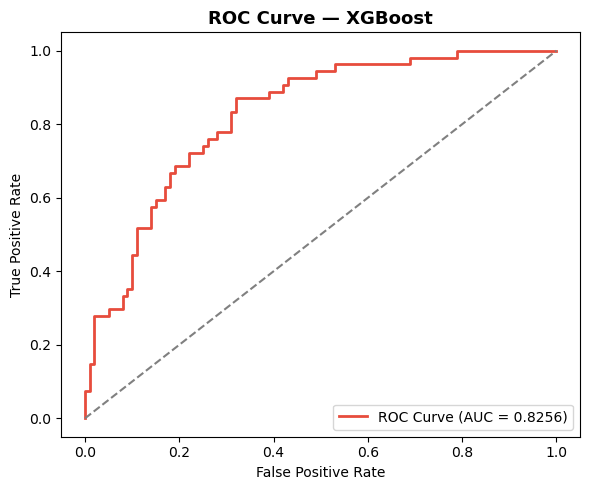

In [36]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score   = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve — XGBoost", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

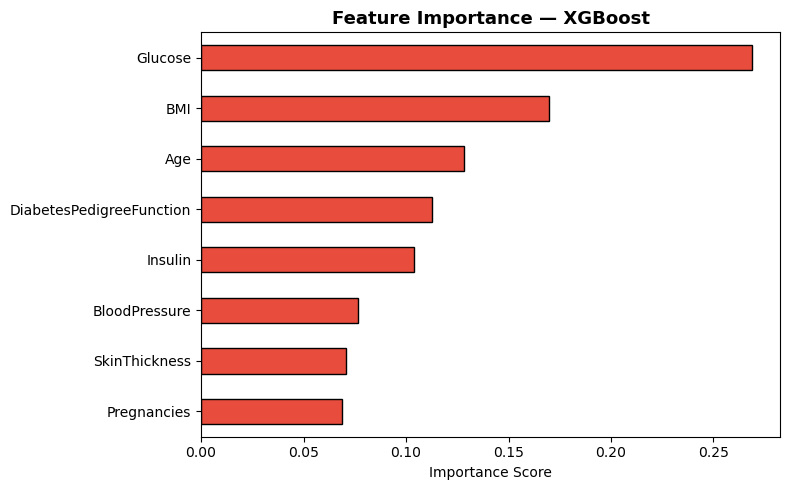

Top 3 most important features:
Glucose    0.269004
BMI        0.169629
Age        0.128401
dtype: float64


In [37]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="#e74c3c", edgecolor="black")
plt.title("Feature Importance — XGBoost", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(feat_imp.sort_values(ascending=False).head(3))